# Part I - Standard Portfolio Allocation\n**SAAM Project 2026 - Group BR (North America + Europe / Scope 1+2)**

In [51]:
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = 'data/'

## 1. Load and Reshape Data

In [52]:
# Filter for North America + Europe
static = pd.read_excel(DATA_DIR + 'Static_2025.xlsx')
our_isins = static[static['Region'].isin(['AMER', 'EUR'])]['ISIN'].tolist()

def load_and_reshape(filename, isins):
    """Load Excel, filter by ISIN, pivot to (dates x firms) matrix."""
    df = pd.read_excel(DATA_DIR + filename)
    df = df[df['ISIN'].isin(isins)]
    date_cols = [c for c in df.columns if c not in ['NAME', 'ISIN']]
    matrix = df.set_index('ISIN')[date_cols].T
    matrix.index = pd.to_datetime(matrix.index)
    return matrix.apply(pd.to_numeric, errors='coerce')

prices = load_and_reshape('DS_RI_T_USD_M_2025.xlsx', our_isins)
mktcap = load_and_reshape('DS_MV_T_USD_M_2025.xlsx', our_isins)

# CO2: sum Scope 1 + Scope 2 (yearly, for filtering only)
def load_co2(filename):
    df = pd.read_excel(DATA_DIR + filename)
    year_cols = [c for c in df.columns if isinstance(c, (int, float))]
    return df.set_index('ISIN')[year_cols].apply(pd.to_numeric, errors='coerce')

co2 = load_co2('DS_CO2_SCOPE_1_Y_2025.xlsx').add(
    load_co2('DS_CO2_SCOPE_2_Y_2025.xlsx'), fill_value=0
).ffill(axis=1).loc[lambda df: df.index.isin(our_isins)]

# Risk-free rate
rf = pd.read_excel(DATA_DIR + 'Risk_Free_Rate_2025.xlsx')
rf.columns = ['Date', 'RF']
rf['Date'] = pd.to_datetime(rf['Date'].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
rf = rf.set_index('Date')
rf['RF'] = rf['RF'] / 100 / 12  # annualized % -> monthly decimal

print(f"Loaded: {len(our_isins)} firms (AMER+EUR), {prices.shape[0]} months")
print(f"CO2 data: {len(co2)} firms, Risk-free rate: {len(rf)} months")

Loaded: 1302 firms (AMER+EUR), 314 months
CO2 data: 1302 firms, Risk-free rate: 312 months


## 2. Data Cleaning and Returns

Returns: 313 months x 1302 firms
Period: 2000-01 to 2026-01
Delistings: 112


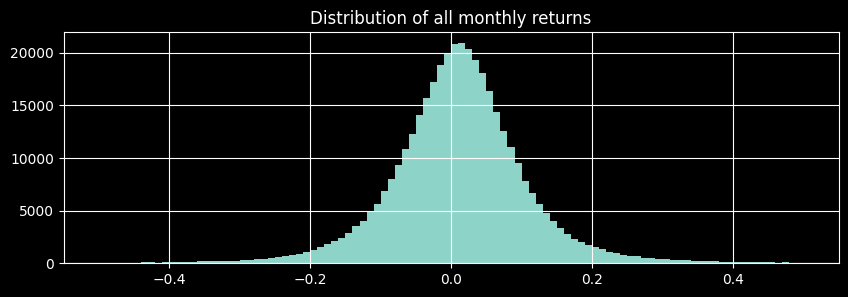

In [53]:
# Remove fully empty firms
prices = prices.dropna(axis=1, how='all')
mktcap = mktcap[prices.columns.intersection(mktcap.columns)]

# Prices below 0.5 -> NaN (per instructions)
prices[prices < 0.5] = np.nan

# Compute simple returns
returns = prices.pct_change().iloc[1:]  # drop first row (no prior price)

# Handle delistings: price valid then NaN -> return = -100%
for col in returns.columns:
    last_valid = prices[col].last_valid_index()
    if last_valid is not None and last_valid < prices.index[-1]:
        next_pos = prices.index.get_loc(last_valid) + 1
        next_date = prices.index[next_pos]
        if next_date in returns.index:
            returns.loc[next_date, col] = -1.0

print(f"Returns: {returns.shape[0]} months x {returns.shape[1]} firms")
print(f"Period: {returns.index[0]:%Y-%m} to {returns.index[-1]:%Y-%m}")
print(f"Delistings: {(returns == -1.0).sum().sum()}")

# Quick look at return distribution
returns.stack().hist(bins=100, range=(-0.5, 0.5), figsize=(10, 3))
plt.title('Distribution of all monthly returns')
plt.show()

## 3. Investment Set + Optimization helpers

In [54]:
def dec(year, index):
    """Get the December date for a given year from a DatetimeIndex."""
    dates = index[(index.month == 12) & (index.year == year)]
    return dates[0] if len(dates) > 0 else None

def get_eligible(year):
    """Firms eligible for investment at end of year Y."""
    window = returns.loc[dec(year-10, returns.index):dec(year, returns.index)]
    
    valid_count = window.notna().sum()        # how many months of data
    zero_pct = (window == 0).sum() / valid_count  # stale price ratio
    has_price = prices.loc[dec(year, prices.index)].notna()  # price exists at year end
    has_co2 = pd.Series({
        isin: co2.loc[isin, :year].notna().any() if isin in co2.index else False
        for isin in window.columns
    })
    
    mask = (valid_count >= 36) & (zero_pct <= 0.5) & has_price & has_co2
    return mask[mask].index.tolist()

def min_variance_weights(year, eligible):
    """Long-only minimum-variance: min w'Σw, s.t. Σw=1, w≥0."""
    window = returns.loc[dec(year-10, returns.index):dec(year, returns.index)]
    ret = window[eligible].fillna(0)
    
    cov = ret.cov().values.copy()
    cov += np.eye(len(eligible)) * 1e-8
    
    w = cp.Variable(len(eligible))
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cov)),
                      [cp.sum(w) == 1, w >= 0])
    prob.solve(solver=cp.OSQP, max_iter=20000, eps_abs=1e-9, eps_rel=1e-9)
    return pd.Series(w.value, index=eligible)

# Check investment set sizes
for y in range(2013, 2025):
    print(f"  {y}: {len(get_eligible(y))} firms")

  2013: 842 firms
  2014: 866 firms
  2015: 898 firms
  2016: 921 firms
  2017: 953 firms
  2018: 1010 firms
  2019: 1101 firms
  2020: 1146 firms
  2021: 1176 firms
  2022: 1175 firms
  2023: 1159 firms
  2024: 1145 firms


## 4. Backtest (2014-2025)

In [55]:
r_vw_list, r_mv_list = [], []

for year in range(2013, 2025):
    eligible = get_eligible(year)
    w_mv = min_variance_weights(year, eligible)
    
    # Months in the next year
    future = returns.loc[returns.index.year == year + 1, eligible].fillna(0)
    
    print(f"{year}: {len(eligible)} firms, {(w_mv > 1e-6).sum()} with weight")
    
    # Min-variance: drift-adjust weights month by month
    w = w_mv.copy()
    for date, row in future.iterrows():
        r_mv_list.append({'Date': date, 'Return': (w * row).sum()})
        w = w * (1 + row)
        w = w / w.sum()
    
    # Value-weighted: use previous month's market cap
    for date in future.index:
        prev = mktcap.index[mktcap.index.get_loc(date) - 1]
        caps = mktcap.loc[prev, eligible].fillna(0)
        w_vw = caps / caps.sum()
        r_vw_list.append({'Date': date, 'Return': (w_vw * future.loc[date]).sum()})

df_vw = pd.DataFrame(r_vw_list).set_index('Date')
df_mv = pd.DataFrame(r_mv_list).set_index('Date')
print(f"\nTotal: {len(df_vw)} monthly returns")

2013: 842 firms, 26 with weight
2014: 866 firms, 32 with weight
2015: 898 firms, 31 with weight
2016: 921 firms, 28 with weight
2017: 953 firms, 32 with weight
2018: 1010 firms, 33 with weight
2019: 1101 firms, 37 with weight
2020: 1146 firms, 38 with weight
2021: 1176 firms, 39 with weight
2022: 1175 firms, 41 with weight
2023: 1159 firms, 33 with weight
2024: 1145 firms, 29 with weight

Total: 144 monthly returns


## 5. Results


Value-Weighted:
  Ann. avg return      +0.114187
  Ann. volatility      +0.142062
  Ann. cum return      +0.109255
  Sharpe ratio         +0.793669
  Min                  -0.131837
  Max                  +0.129131

Minimum-Variance:
  Ann. avg return      +0.043910
  Ann. volatility      +0.142432
  Ann. cum return      +0.034080
  Sharpe ratio         +0.297955
  Min                  -0.201961
  Max                  +0.122533


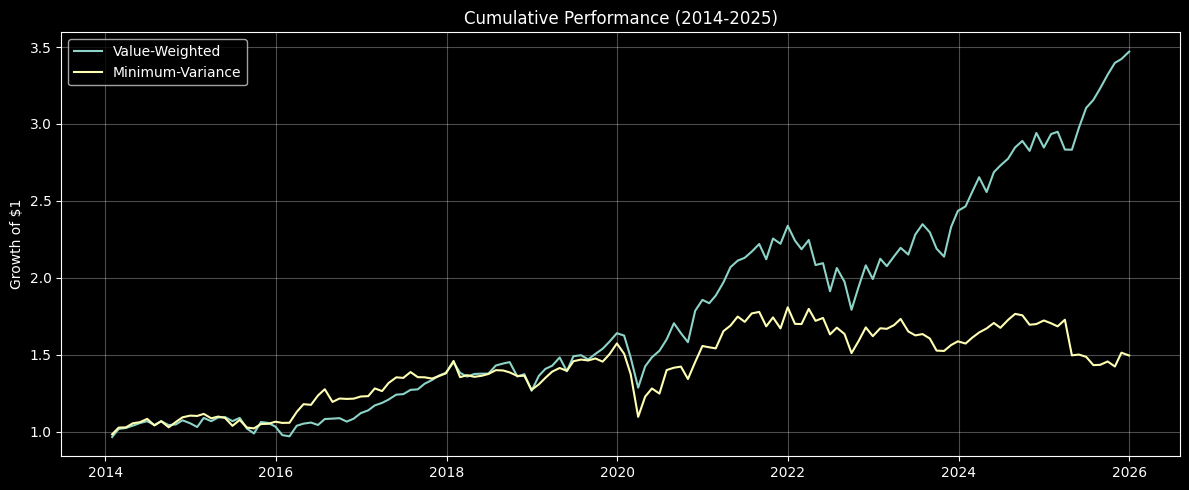

In [56]:
def summary(r, name):
    """Compute and print annualized portfolio statistics."""
    # Match risk-free rate by closest month-end date
    rf_matched = rf['RF'].reindex(r.index, method='nearest')
    excess = r - rf_matched
    stats = {
        'Ann. avg return': r.mean() * 12,
        'Ann. volatility': r.std() * np.sqrt(12),
        'Ann. cum return': (1 + r).prod() ** (12 / len(r)) - 1,
        'Sharpe ratio': excess.mean() / excess.std() * np.sqrt(12),
        'Min': r.min(),
        'Max': r.max(),
    }
    print(f"\n{name}:")
    for k, v in stats.items():
        print(f"  {k:20s} {v:+.6f}")
    return stats

stats_vw = summary(df_vw['Return'], 'Value-Weighted')
stats_mv = summary(df_mv['Return'], 'Minimum-Variance')

# Cumulative return plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot((1 + df_vw['Return']).cumprod(), label='Value-Weighted')
ax.plot((1 + df_mv['Return']).cumprod(), label='Minimum-Variance')
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Performance (2014-2025)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Export to Template

In [57]:
from openpyxl import load_workbook

wb = load_workbook('informations/Template for Part I-SAAM.xlsx')
ws = wb.active

# Summary stats (rows 3-8, col B=VW, C=MV)
for i, key in enumerate(['Ann. avg return', 'Ann. volatility', 'Ann. cum return',
                          'Sharpe ratio', 'Min', 'Max']):
    ws.cell(row=3+i, column=2, value=stats_vw[key])
    ws.cell(row=3+i, column=3, value=stats_mv[key])

# Monthly returns (col E=date, F=VW, G=MV)
for i, date in enumerate(df_vw.index):
    ws.cell(row=3+i, column=5, value=date)
    ws.cell(row=3+i, column=6, value=df_vw.loc[date, 'Return'])
    ws.cell(row=3+i, column=7, value=df_mv.loc[date, 'Return'])

wb.save('Part_I_Results.xlsx')
print(f"Saved Part_I_Results.xlsx ({len(df_vw)} months)")

Saved Part_I_Results.xlsx (144 months)
